# -----------------------------------
# ===========================
# CUSTOMER CHURN PREDICTION
# ===========================
# -----------------------------------

### This project predicts whether a telecom customer is likely to leave the service using Machine Learning techniques.It includes exploratory data analysis (EDA),data preprocessing and feature scaling, model building and evaluation.Multiple models are trained and compared to identify the best-performing approach for improving customer retention strategies.

# =========================
## 1. IMPORT DATASET FROM KAGGLE
# =========================

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [ ]:
import shutil
shutil.copytree(path,"data")

'data'

# =========================
## 1. IMPORT LIBRARIES
# =========================

In [ ]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# =========================
## 2. LOAD DATASET
# =========================

In [ ]:
df = pd.read_csv("/content/data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# =========================
## 3. EXPLORATORY DATA ANALYSIS (EDA)
# =========================

### Dataset Shape

In [ ]:
df.shape

(7043, 21)

### Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Statistical Summary

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Check Missing Values

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### Check Duplicate Values

In [ ]:
df.duplicated().sum()

np.int64(0)

# =========================
## 4. DATA VISUALIZATION
# =========================

## ---------------------------
### Churn Distribution
## ---------------------------

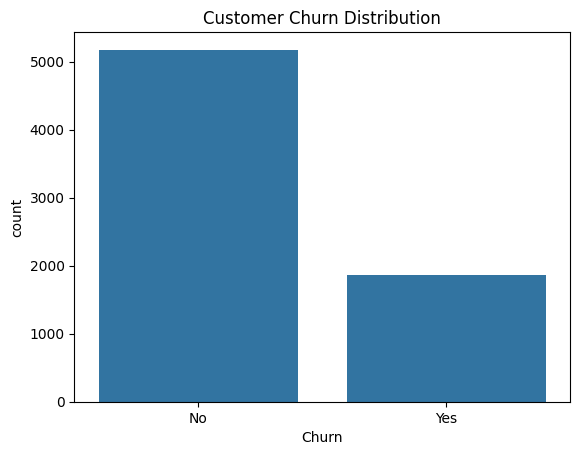

In [ ]:
sns.countplot(x="Churn",data=df)
plt.title("Customer Churn Distribution")
plt.show()

### Insight :
### Customers who left the service are fewer than retained customers.

## ---------------------------
### Monthly Charges Distribution
## ---------------------------

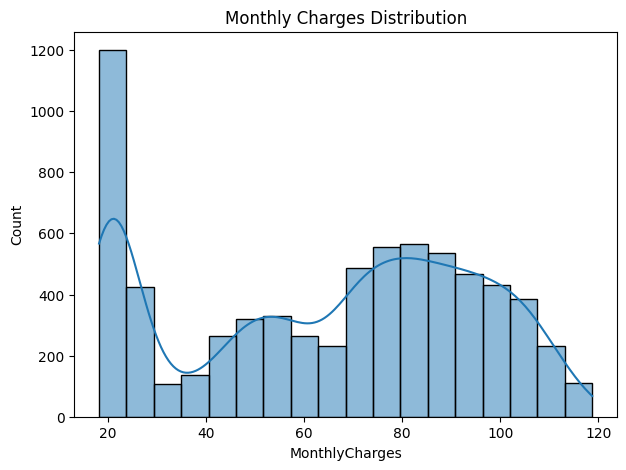

In [ ]:
plt.figure(figsize=(7,5))
sns.histplot(df['MonthlyCharges'], kde=True)
plt.title('Monthly Charges Distribution')
plt.show()

## ---------------------------
### Tenure vs Churn
## ---------------------------

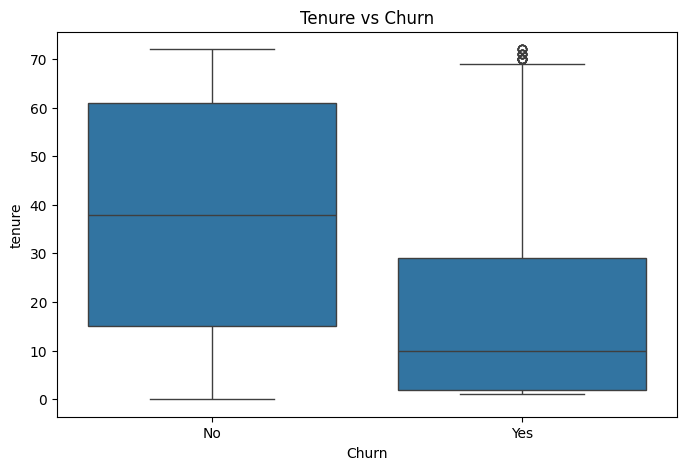

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure vs Churn')
plt.show()

### Insight :
### Customers with lower tenure tend to churn more.

## ---------------------------
### Contract Type vs Churn
## ---------------------------

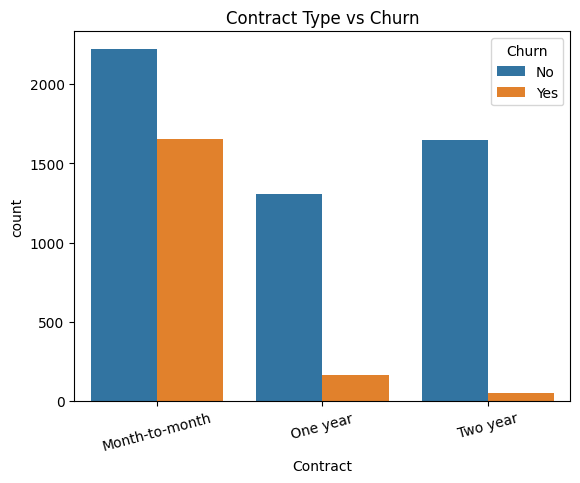

In [ ]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.xticks(rotation=15)
plt.title('Contract Type vs Churn')
plt.show()

### Insight :
### Month-to-month customers show higher churn.

## ---------------------------
### Internet Service vs Churn
## ---------------------------

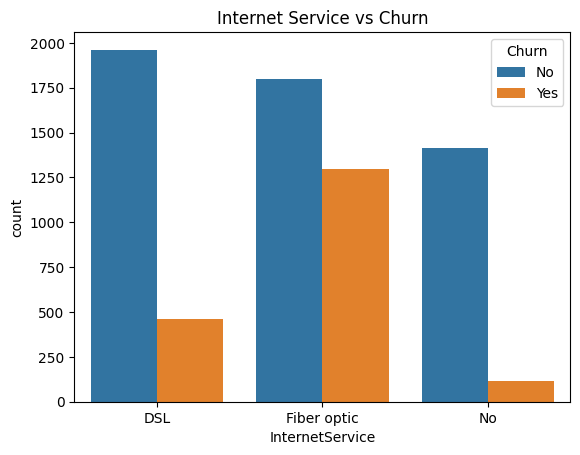

In [ ]:
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title('Internet Service vs Churn')
plt.show()

## ---------------------------
### Payment Method vs Churn
## ---------------------------

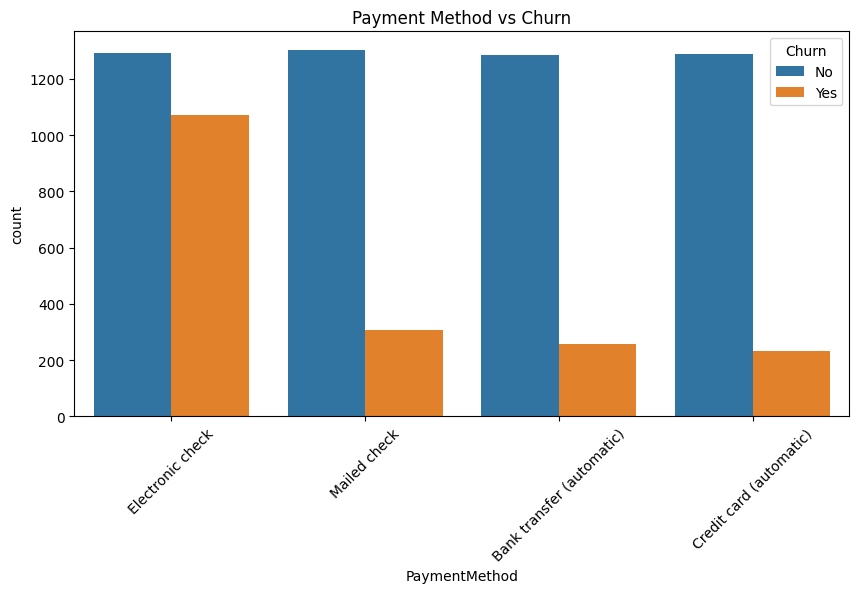

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.title('Payment Method vs Churn')
plt.show()

# =========================
## 5. DATA CLEANING
# =========================

### Drop CostomerID Column

In [ ]:
df.drop("customerID",axis=1,inplace=True)

### Convert TotalCharges to Numeric

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

### Fill Missing Values with Median

In [ ]:
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

/tmp/ipykernel_4251/2840544469.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


# =========================
## 6. LABEL ENCODING
# =========================

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

### Check datatypes after Encoding

In [ ]:
df.dtypes

,0
gender,int64
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
MultipleLines,int64
InternetService,int64
OnlineSecurity,int64
OnlineBackup,int64


# =========================
## 7. CORRELATION HEATMAP
# =========================

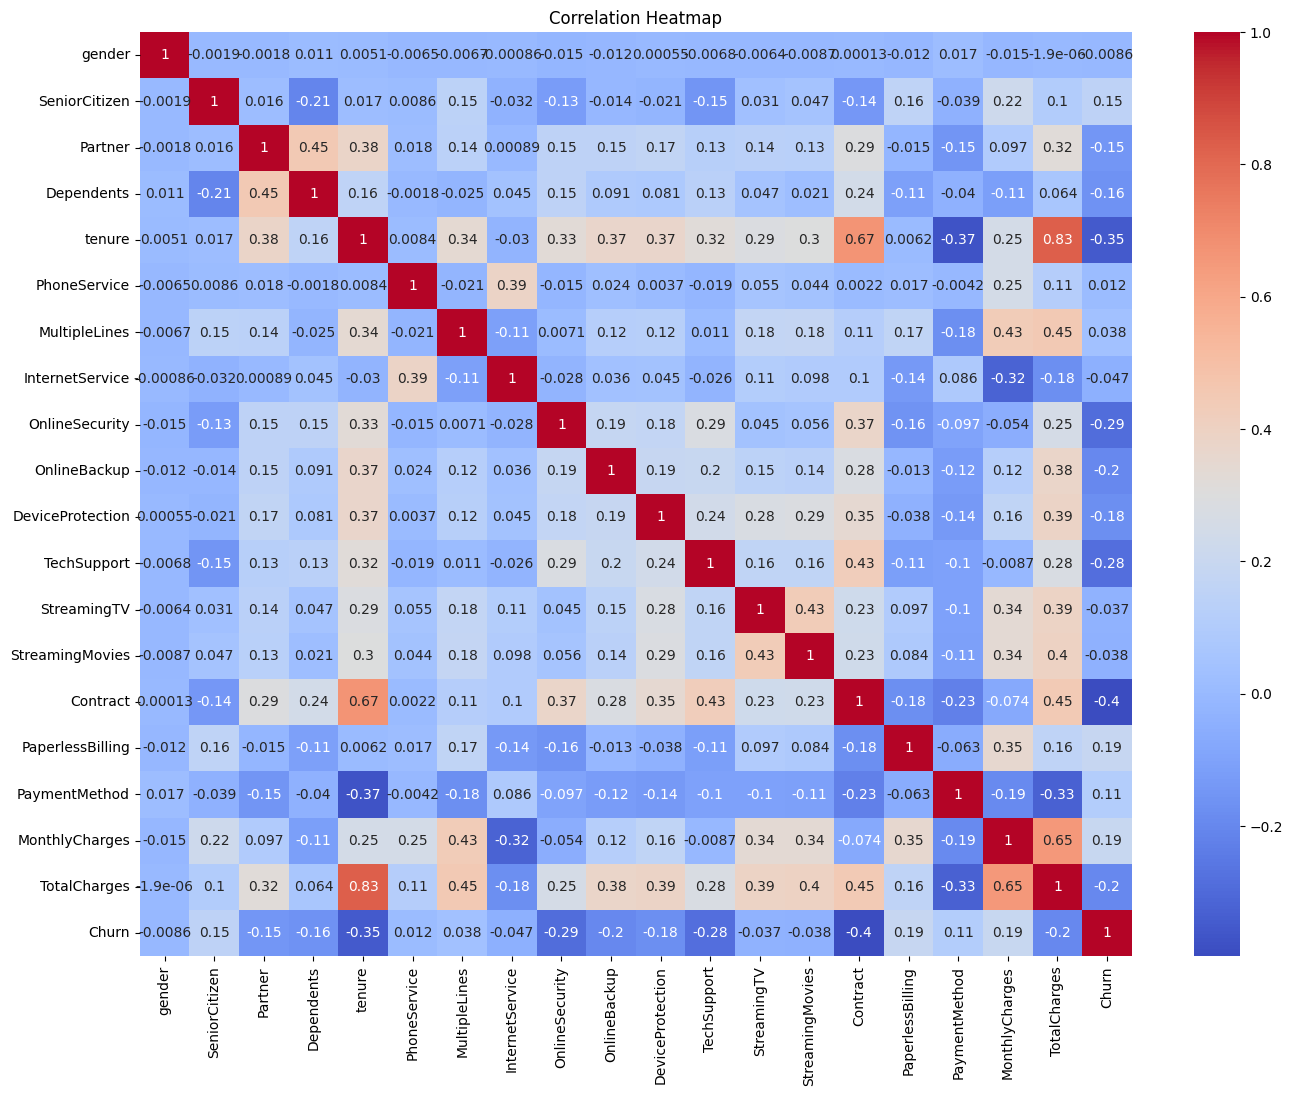

In [ ]:
plt.figure(figsize=(16,12))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# =========================
## 8. FEATURES AND TARGET
# =========================

In [ ]:
x = df.drop('Churn', axis=1)
y = df['Churn']

# =========================
## 9. TRAIN-TEST SPLIT
# =========================

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# =========================
## 10. FEATURE SCALING
### (Used only for Logistic Regressor)
# =========================

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# =========================
## 11. LOGISTIC REGRESSION MODEL
# =========================

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(x_train_scaled, y_train)

y_pred_log_reg = log_reg.predict(x_test_scaled)

# =========================
## 12. RANDOM FOREST MODEL
# =========================

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rd_ft = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rd_ft.fit(x_train, y_train)

y_pred_rd_ft = rd_ft.predict(x_test)

# =========================
## 13. LIGHTGBM MODEL
# =========================

In [ ]:
from lightgbm import LGBMClassifier

lgb = LGBMClassifier()
lgb.fit(x_train, y_train)

y_pred_lgb = lgb.predict(x_test)

[LightGBM] [Info] Number of positive: 1496, number of negative: 4138
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001121 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 626
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265531 -> initscore=-1.017418
[LightGBM] [Info] Start training from score -1.017418


# =========================
## 14.MODEL ACCURACY COMPARISON
# =========================

In [ ]:
log_acc = accuracy_score(y_test, y_pred_log_reg)
rf_acc = accuracy_score(y_test, y_pred_rd_ft)
lgb_acc = accuracy_score(y_test, y_pred_lgb)

print("Logistic Regression Accuracy:", log_acc)
print("Random Forest Accuracy:", rf_acc)
print("LightGBM Accuracy:", lgb_acc)

Logistic Regression Accuracy: 0.815471965933286
Random Forest Accuracy: 0.8097941802696949
LightGBM Accuracy: 0.8076650106458482


# =========================
## 15. CLASSIFICATION REPORTS
# =========================

In [ ]:

print("Logistic Regression Report:\n", classification_report(y_test, y_pred_log_reg))
print("Random Forest Report:\n", classification_report(y_test, y_pred_rd_ft))
print("LightGBM Report:\n", classification_report(y_test, y_pred_lgb))


Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409

Random Forest Report:
               precision    recall  f1-score   support

           0       0.84      0.92      0.88      1036
           1       0.69      0.52      0.59       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409

LightGBM Report:
               precision    recall  f1-score   support

           0       0.85      0.90      0.87      1036
           1       0.67      0.55      0.60       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weig

# =========================
## 16. CONFUSION MATRIX (LOGESTIC REGRESSION)
# =========================

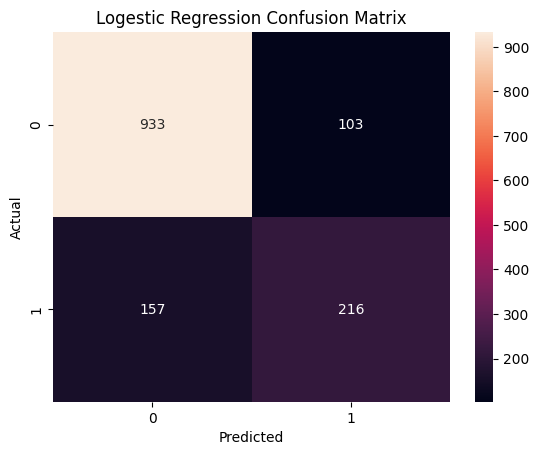

In [ ]:
cm = confusion_matrix(y_test, y_pred_log_reg)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Logestic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================
## 17. MODEL COMPARISON TABLE
# =========================

In [ ]:
results = pd.DataFrame({'Model':[
                         'Logistic Regression',
                         'Random Forest',
                         'LightGBM'
                        ],
                        'Accuracy':[
                            log_acc,
                            rf_acc,
                            lgb_acc
                        ]
})

print("\nModel Comparison:\n")
print(results)


Model Comparison:

                 Model  Accuracy
0  Logistic Regression  0.815472
1        Random Forest  0.809794
2             LightGBM  0.807665


# =========================
## 18. FEATURE IMPORTANCE
# =========================

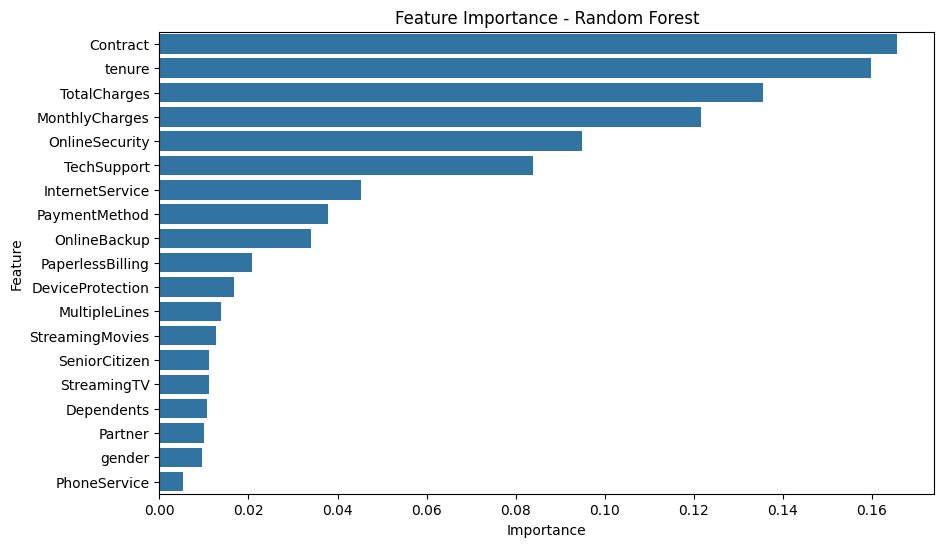

In [ ]:
importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rd_ft.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance - Random Forest")

plt.show()

# =========================
## 19. FINAL CONCLUSION
# =========================

### Project Completed Successfully!

### Conclusion:

### This project predicts telecom customer churn using Machine Learning models such as Logistic Regression, Random Forest, and LightGBM.

### After preprocessing, encoding, scaling, and model evaluation, Logistic Regression achieved the highest accuracy of 81%, while Random Forest and LightGBM achieved 80% accuracy.

### The results indicate that the dataset has mostly linear relationships between customer attributes and churn behavior. Feature importance analysis showed that tenure, monthly charges, and contract type were major factors influencing customer churn.

### This system can help telecom companies identify customers likely to leave the service and improve customer retention strategies.